# Chapter 2, Example 3: Conditional Independence and Graph Separation

Graphical models are useful because graph separation translates into probabilistic statements. This notebook makes that translation explicit for four canonical motifs:

1. an undirected Markov chain;
2. a directed chain;
3. a directed fork;
4. a directed collider.

For each model we construct the full joint distribution and measure dependence using mutual information and conditional mutual information. The collider demonstrates the important phenomenon of explaining away: two independent causes become dependent after conditioning on their common effect.

## 1. Information measures

For discrete variables $X$ and $Z$, mutual information is

$$
I(X;Z)
=
\sum_{x,z}p(x,z)
\log\left(\frac{p(x,z)}{p(x)p(z)}\right).
$$

It vanishes exactly when $X$ and $Z$ are independent.

Conditional mutual information is

$$
I(X;Z\mid Y)
=
\sum_{x,y,z}p(x,y,z)
\log\left(
\frac{p(x,z\mid y)}{p(x\mid y)p(z\mid y)}
\right).
$$

It vanishes exactly when $X$ and $Z$ are conditionally independent given $Y$.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 220})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def normalize(joint):
    joint = np.asarray(joint, dtype=float)
    total = joint.sum()
    if total <= 0:
        raise ValueError("Joint table must have positive mass.")
    return joint / total


def mutual_information_xz(joint):
    p = normalize(joint)
    pxz = p.sum(axis=1)
    px = pxz.sum(axis=1)
    pz = pxz.sum(axis=0)
    value = 0.0
    for x, z in product([0, 1], repeat=2):
        if pxz[x, z] > 0:
            value += pxz[x, z] * np.log(pxz[x, z] / (px[x] * pz[z]))
    return value


def conditional_mutual_information_xz_given_y(joint):
    p = normalize(joint)
    value = 0.0
    py = p.sum(axis=(0, 2))
    for y in [0, 1]:
        if py[y] == 0:
            continue
        conditional = p[:, y, :] / py[y]
        px = conditional.sum(axis=1)
        pz = conditional.sum(axis=0)
        for x, z in product([0, 1], repeat=2):
            if conditional[x, z] > 0:
                value += py[y] * conditional[x, z] * np.log(
                    conditional[x, z] / (px[x] * pz[z])
                )
    return value

## 2. Four graph motifs

The outer variables are denoted by $X$ and $Z$, and the middle variable by $Y$.

- In an undirected chain, $Y$ separates $X$ from $Z$.
- In a directed chain, information flows through $Y$.
- In a fork, $Y$ is a common cause.
- In a collider, $Y$ is a common effect.

The first three motifs imply $X\perp Z\mid Y$. The collider instead implies $X\perp Z$ before conditioning, but conditioning on $Y$ generally creates dependence.

/tmp/ipykernel_885/1345872931.py:16: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/tmp/ipykernel_885/1345872931.py:16: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


Saved: figs/ch02_03_graph_separation_motifs.pdf
Saved: figs/ch02_03_graph_separation_motifs.png


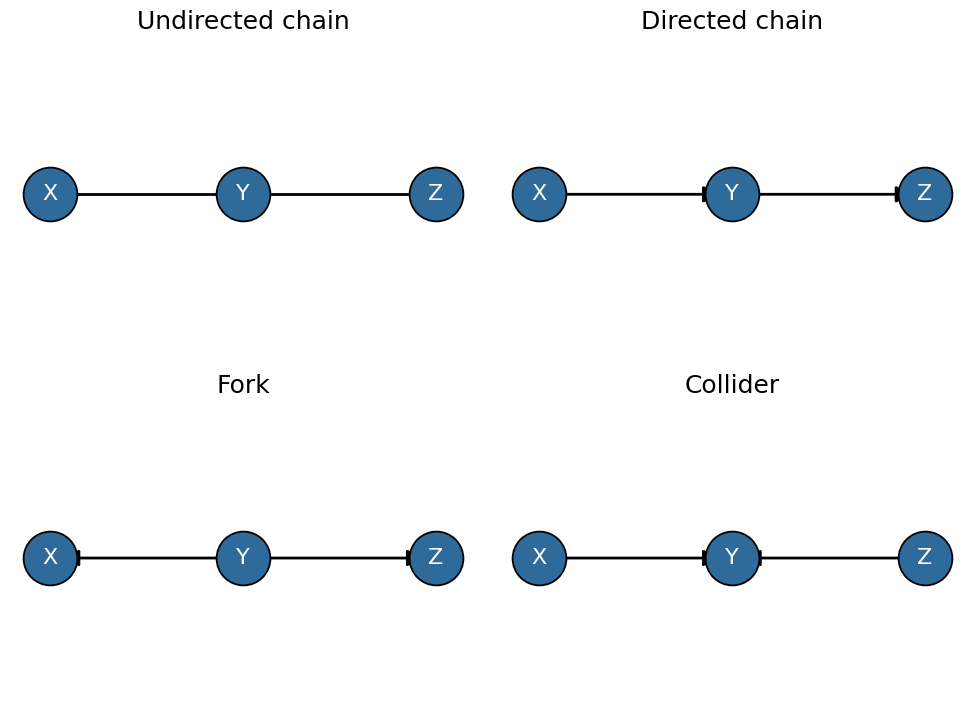

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

motifs = [
    ("Undirected chain", [("X", "Y"), ("Y", "Z")], False),
    ("Directed chain", [("X", "Y"), ("Y", "Z")], True),
    ("Fork", [("Y", "X"), ("Y", "Z")], True),
    ("Collider", [("X", "Y"), ("Z", "Y")], True),
]
pos = {"X": (0, 0), "Y": (1.5, 0), "Z": (3, 0)}
for ax, (title, edges, directed) in zip(axes.flat, motifs):
    graph = nx.DiGraph() if directed else nx.Graph()
    graph.add_nodes_from(["X", "Y", "Z"])
    graph.add_edges_from(edges)
    nx.draw_networkx_nodes(graph, pos, node_size=1500, node_color="#2F6B9A", edgecolors="black", linewidths=1.3, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=16, font_color="white", ax=ax)
    nx.draw_networkx_edges(
        graph, pos, width=2.0, arrows=directed, arrowsize=24,
        connectionstyle="arc3,rad=0.0", ax=ax
    )
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch02_03_graph_separation_motifs")
plt.show()

## 3. Undirected Markov chain

We use spin variables $s_X,s_Y,s_Z\in\{-1,+1\}$ and define

$$
p(x,y,z)
\propto
\exp\left(J_{XY}s_Xs_Y+J_{YZ}s_Ys_Z+h_Ys_Y\right).
$$

The factorization contains no direct interaction between $X$ and $Z$. They are usually dependent marginally because influence propagates through $Y$, but they become independent after conditioning on $Y$.

In [3]:
def undirected_chain_joint(Jxy=0.95, Jyz=-0.75, hy=0.20):
    joint = np.zeros((2, 2, 2))
    for x, y, z in product([0, 1], repeat=3):
        sx, sy, sz = 2 * x - 1, 2 * y - 1, 2 * z - 1
        joint[x, y, z] = np.exp(Jxy * sx * sy + Jyz * sy * sz + hy * sy)
    return normalize(joint)


p_mrf = undirected_chain_joint()
print("MRF I(X;Z)       =", mutual_information_xz(p_mrf))
print("MRF I(X;Z | Y)   =", conditional_mutual_information_xz_given_y(p_mrf))
assert conditional_mutual_information_xz_given_y(p_mrf) < 1e-12

MRF I(X;Z)       = 0.10908228437283721
MRF I(X;Z | Y)   = 1.5298634897626793e-17


## 4. Directed chain and fork

A directed chain factorizes as

$$
p(x,y,z)=p(x)p(y\mid x)p(z\mid y).
$$

A fork factorizes as

$$
p(x,y,z)=p(y)p(x\mid y)p(z\mid y).
$$

Although the causal interpretations differ, both imply the same conditional-independence statement $X\perp Z\mid Y$.

In [4]:
def bernoulli_probability(value, probability_one):
    return probability_one if value == 1 else 1.0 - probability_one


def directed_chain_joint():
    p = np.zeros((2, 2, 2))
    for x, y, z in product([0, 1], repeat=3):
        py1 = 0.82 if x == 1 else 0.18
        pz1 = 0.88 if y == 1 else 0.12
        p[x, y, z] = (
            bernoulli_probability(x, 0.35)
            * bernoulli_probability(y, py1)
            * bernoulli_probability(z, pz1)
        )
    return normalize(p)


def fork_joint():
    p = np.zeros((2, 2, 2))
    for x, y, z in product([0, 1], repeat=3):
        px1 = 0.86 if y == 1 else 0.16
        pz1 = 0.78 if y == 1 else 0.22
        p[x, y, z] = (
            bernoulli_probability(y, 0.45)
            * bernoulli_probability(x, px1)
            * bernoulli_probability(z, pz1)
        )
    return normalize(p)


p_chain = directed_chain_joint()
p_fork = fork_joint()
for name, joint in [("directed chain", p_chain), ("fork", p_fork)]:
    print(f"{name:15s} I(X;Z) = {mutual_information_xz(joint):.8f}, "
          f"I(X;Z | Y) = {conditional_mutual_information_xz_given_y(joint):.3e}")
    assert conditional_mutual_information_xz_given_y(joint) < 1e-12

directed chain  I(X;Z) = 0.11277962, I(X;Z | Y) = 9.605e-17
fork            I(X;Z) = 0.07768554, I(X;Z | Y) = -6.375e-18


## 5. Collider and explaining away

For the collider,

$$
p(x,y,z)=p(x)p(z)p(y\mid x,z).
$$

The root variables $X$ and $Z$ are independent. We choose a noisy-OR-like conditional table for $Y$. Observing the effect $Y=1$ creates competition between the two possible causes. Knowledge that one cause is present makes the other less necessary, and the causes become conditionally dependent.

In [5]:
def collider_joint():
    p_y1 = np.array([
        [0.04, 0.72],
        [0.68, 0.95],
    ])
    p = np.zeros((2, 2, 2))
    for x, y, z in product([0, 1], repeat=3):
        p[x, y, z] = (
            bernoulli_probability(x, 0.35)
            * bernoulli_probability(z, 0.55)
            * bernoulli_probability(y, p_y1[x, z])
        )
    return normalize(p)


p_collider = collider_joint()
print("Collider I(X;Z)       =", mutual_information_xz(p_collider))
print("Collider I(X;Z | Y)   =", conditional_mutual_information_xz_given_y(p_collider))
assert mutual_information_xz(p_collider) < 1e-12
assert conditional_mutual_information_xz_given_y(p_collider) > 1e-3

Collider I(X;Z)       = 0.0
Collider I(X;Z | Y)   = 0.05165037625887925


## 6. Quantitative comparison

The next figure compares marginal and conditional dependence. Values are measured in nats because the logarithm is natural.

,model,I(X;Z),I(X;Z|Y)
0,Undirected\nchain,0.109082,1.529863e-17
1,Directed\nchain,0.112780,9.604761e-17
2,Fork,0.077686,-6.374901e-18
3,Collider,0.000000,5.165038e-02


Saved: figs/ch02_03_mutual_information_comparison.pdf
Saved: figs/ch02_03_mutual_information_comparison.png


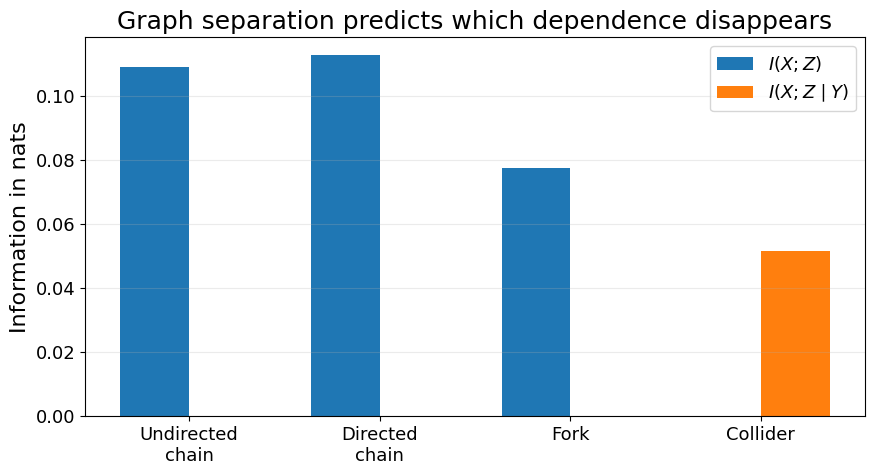

In [6]:
models = {
    "Undirected\nchain": p_mrf,
    "Directed\nchain": p_chain,
    "Fork": p_fork,
    "Collider": p_collider,
}
summary = pd.DataFrame({
    "model": list(models),
    "I(X;Z)": [mutual_information_xz(j) for j in models.values()],
    "I(X;Z|Y)": [conditional_mutual_information_xz_given_y(j) for j in models.values()],
})
display(summary)

positions = np.arange(len(summary))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(positions - 0.18, summary["I(X;Z)"], width=0.36, label=r"$I(X;Z)$")
ax.bar(positions + 0.18, summary["I(X;Z|Y)"], width=0.36, label=r"$I(X;Z\mid Y)$")
ax.set_xticks(positions, summary["model"])
ax.set_ylabel("Information in nats")
ax.set_title("Graph separation predicts which dependence disappears")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_03_mutual_information_comparison")
plt.show()

## 7. Visualizing explaining away

Before conditioning, the collider roots have a product distribution. After conditioning on $Y=1$, the conditional table no longer factors into independent row and column marginals.

Saved: figs/ch02_03_collider_explaining_away.pdf


Saved: figs/ch02_03_collider_explaining_away.png


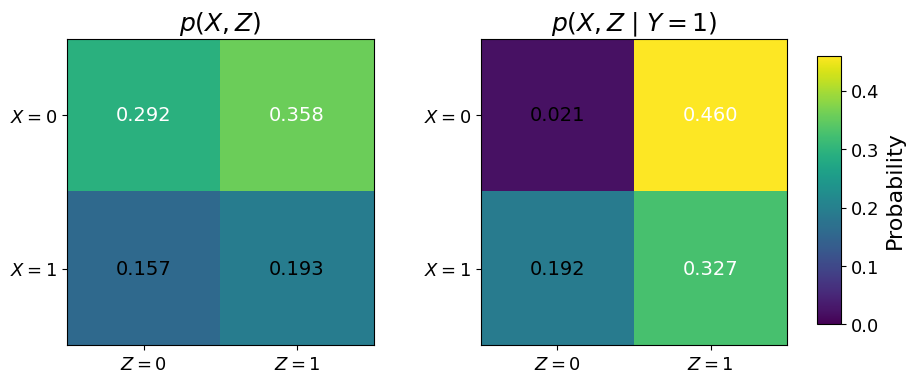

In [7]:
pxz = p_collider.sum(axis=1)
pxz_given_y1 = p_collider[:, 1, :] / p_collider[:, 1, :].sum()

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.2))
for ax, table, title in [
    (axes[0], pxz, r"$p(X,Z)$"),
    (axes[1], pxz_given_y1, r"$p(X,Z\mid Y=1)$"),
]:
    image = ax.imshow(table, vmin=0, vmax=max(pxz.max(), pxz_given_y1.max()))
    for x, z in product([0, 1], repeat=2):
        value = table[x, z]
        threshold = 0.55 * max(pxz.max(), pxz_given_y1.max())
        text_color = "white" if value > threshold else "black"
        ax.text(z, x, f"{value:.3f}", ha="center", va="center", color=text_color, fontsize=14)
    ax.set_xticks([0, 1], [r"$Z=0$", r"$Z=1$"])
    ax.set_yticks([0, 1], [r"$X=0$", r"$X=1$"])
    ax.set_title(title)
fig.subplots_adjust(right=0.86, wspace=0.35)
cax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
fig.colorbar(image, cax=cax, label="Probability")
save_figure(fig, "ch02_03_collider_explaining_away")
plt.show()

## 8. Interpretation

Graph separation is a structural statement, while mutual information is a quantitative statement. In these exact examples the two agree:

- an undirected separator blocks all paths;
- a non-collider middle node blocks a directed path after conditioning;
- a collider blocks a path before conditioning but opens it after conditioning on the collider or one of its descendants.

These principles justify local graphical representations and later determine which messages, factors, or conditionals must be computed.

## 9. Exercises

### Exercise 1: Weaken an interaction

Vary $J_{XY}$ in the undirected chain. Plot both information measures and explain why conditional mutual information remains zero.

### Exercise 2: Deterministic directed chain

Make the conditional tables increasingly deterministic. Study the limiting value of $I(X;Z)$ while verifying $I(X;Z\mid Y)=0$.

### Exercise 3: Conditioning on a collider value

Compute $I(X;Z\mid Y=0)$ and $I(X;Z\mid Y=1)$ separately. Which observation creates the stronger dependence, and why?

### Exercise 4: Reverse one arrow

Replace the collider by $X\leftarrow Y\leftarrow Z$. Reconstruct the joint distribution and predict the two information measures before computing them.

### Exercise 5: Four-node separation

Create an undirected chain $W-X-Y-Z$. Verify that $W\perp Z\mid X$ and $W\perp Z\mid Y$, then test conditioning on both variables.

### Exercise 6: Statistical estimation

Draw samples from each exact joint distribution. Estimate mutual information from empirical counts and study finite-sample bias.